In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
rng = np.random.default_rng(0)
h, w = 200, 400
barcode = np.full((h, w), 255, dtype=np.uint8)

x = 20
while x < w - 40:
    bar = int(rng.integers(3, 12))
    barcode[20:h - 20, x:x + bar] = 0
    x += bar + int(rng.integers(3, 12))

barcode.shape

(200, 400)

In [3]:
k = 0.5
shear = np.array([[1, k, 0], [0, 1, 0]], dtype=np.float64)
slanted = cv2.warpAffine(barcode, shear, (w + int(k * h), h), borderValue=255)

unshear = np.array([[1, -k, 0], [0, 1, 0]], dtype=np.float64)
fixed = cv2.warpAffine(slanted, unshear, (w, h), borderValue=255)

print('max difference from original:', np.abs(fixed.astype(int) - barcode.astype(int)).max())

max difference from original: 64


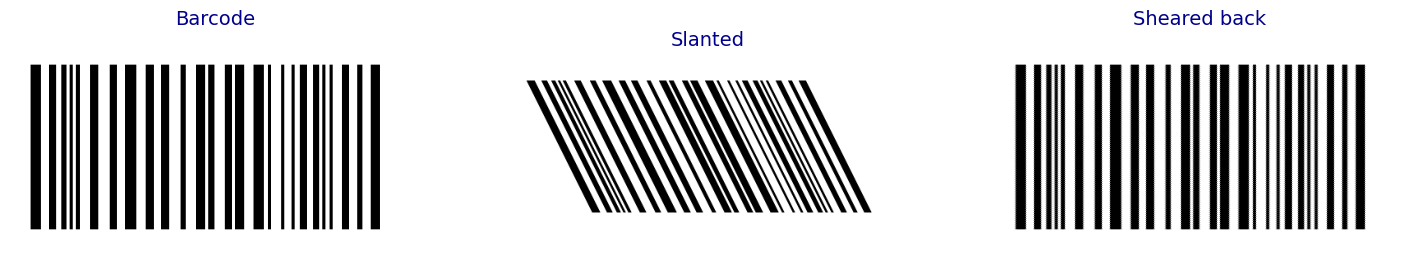

In [4]:
panels = [('Barcode', barcode), ('Slanted', slanted), ('Sheared back', fixed)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

for ax, (title, im) in zip(axes, panels):
    ax.imshow(im, cmap='gray')
    ax.axis('off')
    ax.set_title(title, fontsize=14, color='darkblue', pad=15)

plt.show()

In [5]:
os.makedirs('output', exist_ok=True)
cv2.imwrite('output/task3_barcode.png', fixed)

True

Shear matrix is [[1, k], [0, 1]] so x' = x + k*y. Every row moves sideways by an amount that depends on its y, which is what makes the vertical bars lean. The slant here is 100 px over 200 px of height so k = 0.5.

To fix it I shear the other way with -k. Shear by k and then by -k cancels out. Canvas width grows by k*h when slanting (400 to 500) and goes back to 400 when fixing.

Difference from the original is in the output above, the bars are straight rectangles again.